# SE4AI Lab Session 3

---

## How To Leverage The Hidden Power Of Explainability

In this Lab session we will see how to understand how a model works and behave internally using Explainable AI. We will use LIME and SHAP on tabular data to show how to use them, read the information given by these methods. For educational sake, we will implement different ML methods starting from linear model up to neural networks to show how the explainability techniques works in all of these context.

In [ ]:
!pip install interpret
!pip install lime
!pip install shap
!pip install pandas
!pip install seaborn
!pip install anchor
!pip install joblib
!pip install 'aif360[inFairness]'
!pip install innvestigate
!pip install keras
!pip install tensorflow


[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of p

In this GitHub repository I have dumped the dataset from the first lecture after all the data cleaning, so we have a clean starting point. After in the lecture, we will also see a comparison between a model trained in this lab session with one trained in the lab session on fairness and privacy to check if and how the models behave differently.

In [ ]:
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
df = pd.read_csv('SE4AI_Lab_3/output.csv')

bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['is_recid','decile_score'])
y = df['is_recid']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

X = X_smote
y = y_smote

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Let's kick off our exploration with a straightforward yet powerful approach: the Stochastic Gradient Descent (SGD) Classifier.
This model, known for its simplicity and efficiency, is perfect for handling large datasets.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define a dictionary for the grid of hyperparameters to be tested.
param_grid = {
    'loss': [
        'hinge',  # Used for creating a linear Support Vector Machine (SVM).
        'log',  # Logistic regression loss; gives logistic regression, a probabilistic classifier.
        'modified_huber',  # A smooth loss that brings robustness to outliers as compared to 'hinge'.
        'squared_hinge',  # Squared hinge loss. More sensitive to outliers than 'hinge'.
        'perceptron',  # Loss used with the perceptron algorithm.
    ],
    'penalty': [
        'l2',  # Adds a penalty proportional to the sum of the squares of the coefficients.
        'l1',  # Adds a penalty proportional to the sum of the absolute values of the coefficients (produces sparse solutions).
        'elasticnet',  # A combination of both L1 and L2 regularization. It combines penalties from both L1 and L2.
    ],
    'alpha': [
        0.0001,  # A smaller alpha results in less regularization (more complex models).
        0.001,  # A moderate level of alpha that provides a balance between regularization and model complexity.
        0.01,  # Higher alpha increases regularization strength, useful to prevent overfitting but might lead to underfitting.
        0.1  # Very high regularization, significantly penalizes the size of coefficient values.
    ],
    'max_iter': [1000, 2000, 3000, 5000, 10000, 15000, 20000]  # Different maximum numbers of passes over the training data.

}

# Instantiate the SGDClassifier. Configure it to stop early if validation performance does not improve.
sgd = SGDClassifier(
    tol=1e-3,  # Tolerance for the stopping criteria.
    early_stopping=True,  # Enable early stopping.
    validation_fraction=0.2,  # Fraction of training data to use as validation set for early stopping.
    n_iter_no_change=5  # Number of iterations with no improvement to wait before stopping the training.
)

# Set up GridSearch with the classifier, the parameter grid, and other settings.
grid_search = GridSearchCV(
    sgd,  # The classifier to optimize.
    param_grid,  # The grid of parameters to search.
    cv=5,  # Number of folds in k-fold cross-validation.
    scoring='accuracy'  # Scoring method to use: here it optimizes for classification accuracy.
)

# Fit the GridSearchCV to the training data to find the best parameters.
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

sgd_best_model = grid_search.best_estimator_
y_pred = sgd_best_model.predict(X_test)

Best parameters: {'alpha': 0.01, 'loss': 'modified_huber', 'max_iter': 15000, 'penalty': 'l1'}
Best cross-validation score: 0.64


Now we will plot the confusion matrix of the model

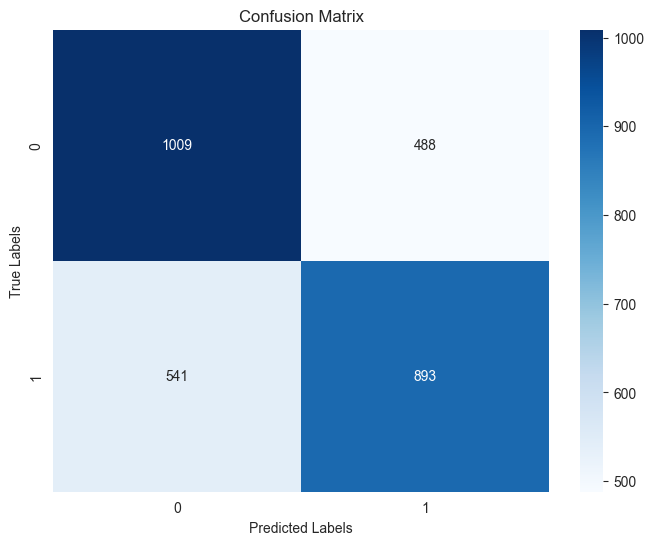

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66      1497
           1       0.65      0.62      0.63      1434

    accuracy                           0.65      2931
   macro avg       0.65      0.65      0.65      2931
weighted avg       0.65      0.65      0.65      2931



As we can see, the performance of the linear model are relatively poor. We proceed to apply LIME to the linear model to see how the model behave and the feature importance of each

In [ ]:
from interpret.blackbox import LimeTabular
from interpret import show

lime = LimeTabular(data=X_train, random_state=42, model=sgd_best_model)
lime_local = lime.explain_local(X_test[-50:], y_test[-50:], name='LIME')
show(lime_local)

<!-- http://127.0.0.1:7001/11066083312/ -->

We fix the index 9 and we will follow this specific instance of the dataset since it has low residual over the correct prediction performed by the model. Now we want to assess if the explanations given by LIME and the one that we will have using SHAP shows according results (SPOILER: they don't).

In [ ]:
import shap

index_to_check = 9

background = shap.maskers.Independent(X, max_samples=1000)
explainer_sgd = shap.Explainer(sgd_best_model.predict, background, seed=42)
shap_values_sgd = explainer_sgd(X)

PermutationExplainer explainer: 14653it [11:34, 20.75it/s]                           


After the calculation of the Shapely Values of the model, we start to analyze how each feature contribute to the final prediction. The first plot that we use is the partial dependence plot, fixing the priors count feature (the specific choice of this feature will be clear later). This specific plot is obtained by fixing one feature value and visualize the course of the function.

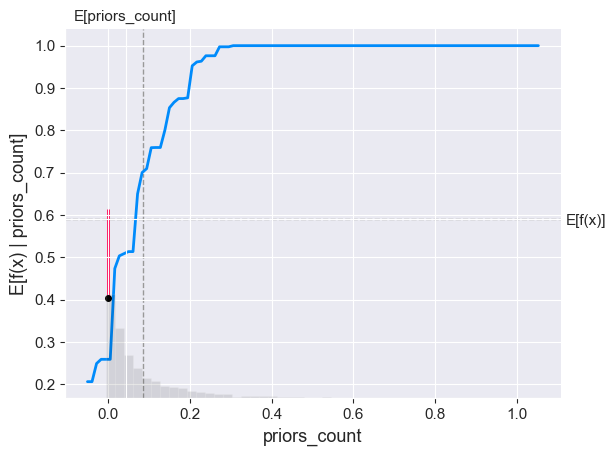

In [ ]:
feature = "priors_count"

shap.partial_dependence_plot(
    feature,                        # The feature for which partial dependence plots will be generated
    sgd_best_model.predict,         # The model's predict function
    X,                              # The dataset
    model_expected_value=True,      # Whether to include the model's expected value in the plot
    feature_expected_value=True,    # Whether to include the feature's expected value in the plot
    show=True,                      # Whether to display the plots
    ice=False,                      # Whether to use individual conditional expectation plots
    shap_values=shap_values_sgd[index_to_check:index_to_check+1:]  # SHAP values for the given feature
)

In this case, we see that fixing priors count we have a continues growth, that express that the model heavily rely on this feature since an high value of it says that the outcome is 1 (so predicted to be recidive-prone )

The Waterfall plot visualize the impact on the prediction that each feature have on it. Since is relative to one feature, this is a local explanation

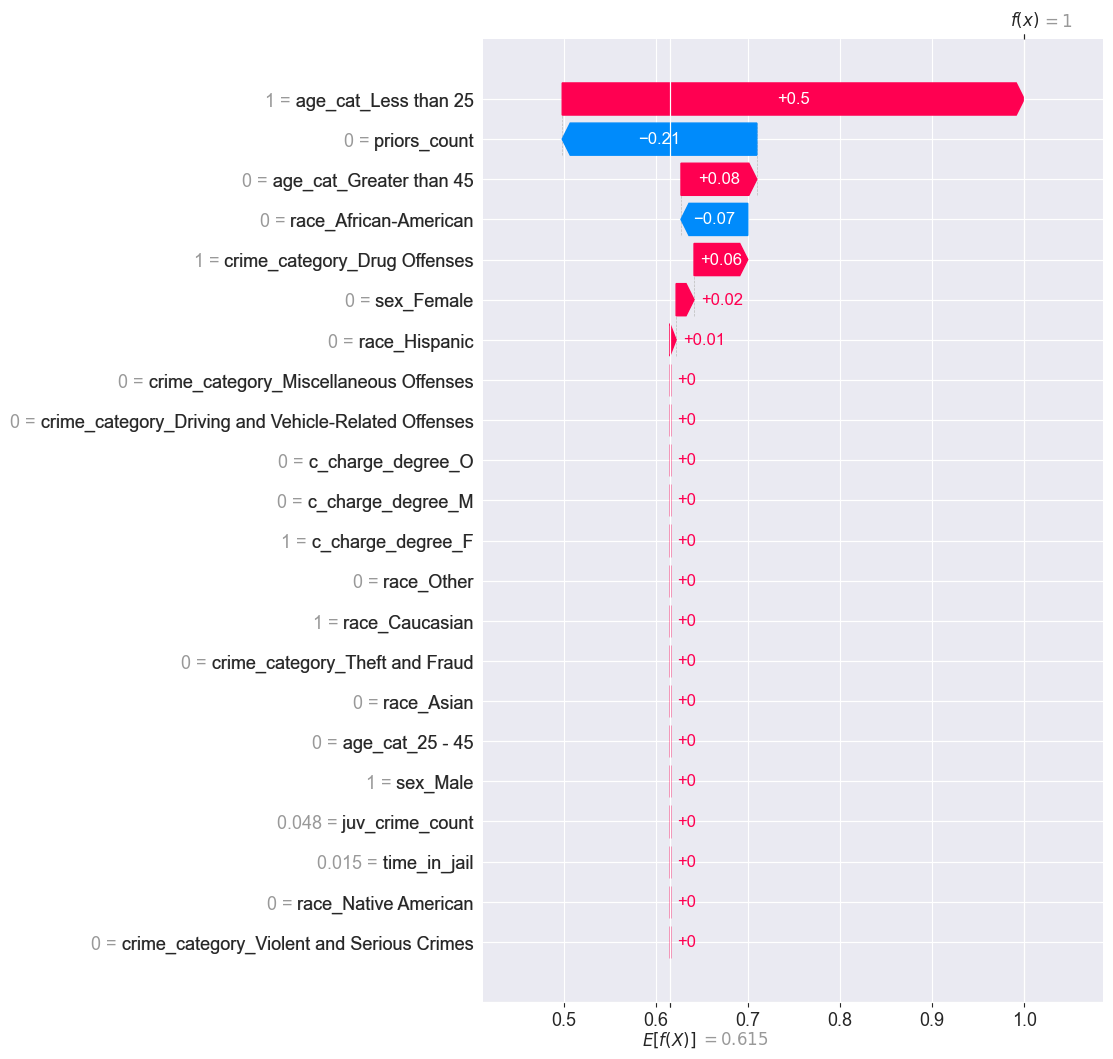

In [ ]:
shap.plots.waterfall(shap_values_sgd[index_to_check], max_display=23)

The Beewsarm plot is relative to the whole model behavior, and is useful to visualize the Shapely Values distribution of each feature (represented by the position on the X axis and the height in the Y axis) and also the impact that the value has on the outcome (represented by the color)

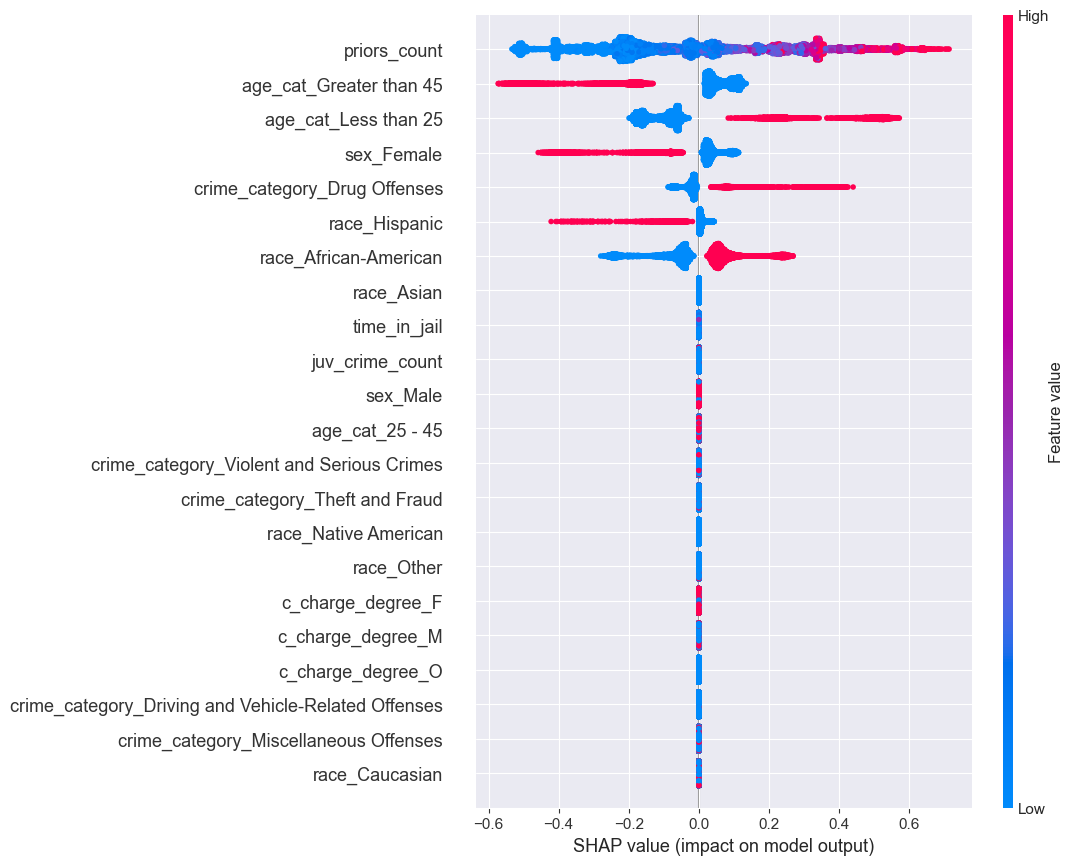

In [ ]:
shap.plots.beeswarm(shap_values_sgd, max_display=23, order=shap_values_sgd.abs.max(0))

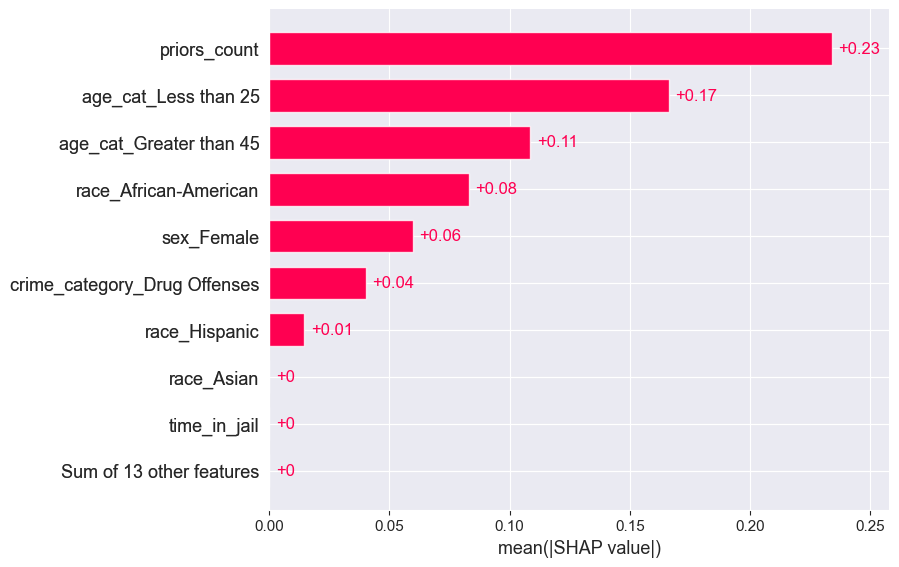

In [ ]:
shap.plots.bar(shap_values_sgd.abs.mean(axis=0))

Now we're ready to take a step up in complexity by introducing a Decision Tree model. Decision Trees are versatile and intuitive models that can capture complex relationships in data without requiring extensive preprocessing

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred = dt_clf.predict(X_test)

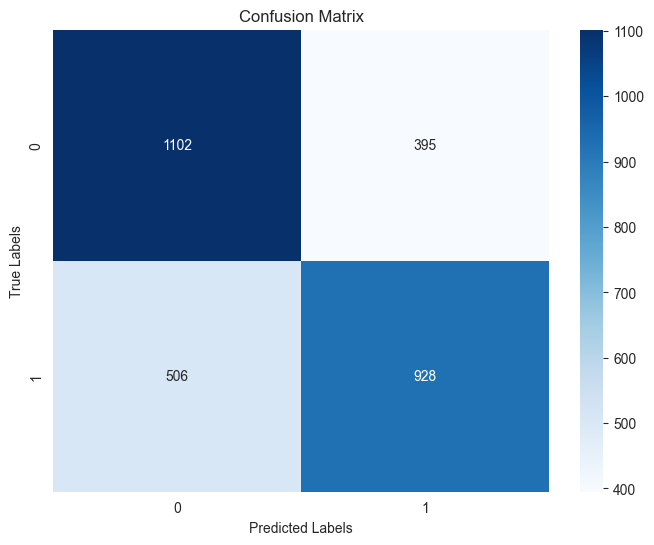

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.74      0.71      1497
           1       0.70      0.65      0.67      1434

    accuracy                           0.69      2931
   macro avg       0.69      0.69      0.69      2931
weighted avg       0.69      0.69      0.69      2931



In [ ]:
lime = LimeTabular(data=X_train, random_state=42, model=dt_clf)
lime_local = lime.explain_local(X_test[-50:], y_test[-50:], name='LIME')
show(lime_local)

<!-- http://127.0.0.1:7001/12808758528/ -->

In [ ]:
explainer_dt = shap.Explainer(dt_clf.predict, X, seed=42)
shap_values_dt = explainer_dt(X)

PermutationExplainer explainer: 14653it [01:53, 117.80it/s]                           


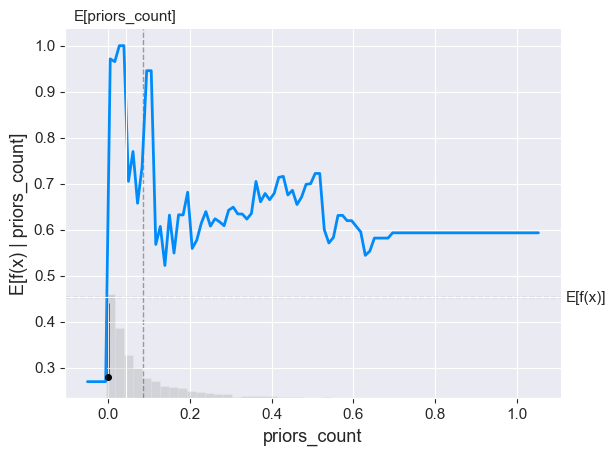

In [ ]:
shap.partial_dependence_plot(
    feature, dt_clf.predict, X, model_expected_value=True,
    feature_expected_value=True, show=True, ice=False,
    shap_values=shap_values_dt[index_to_check:index_to_check+1:]
)

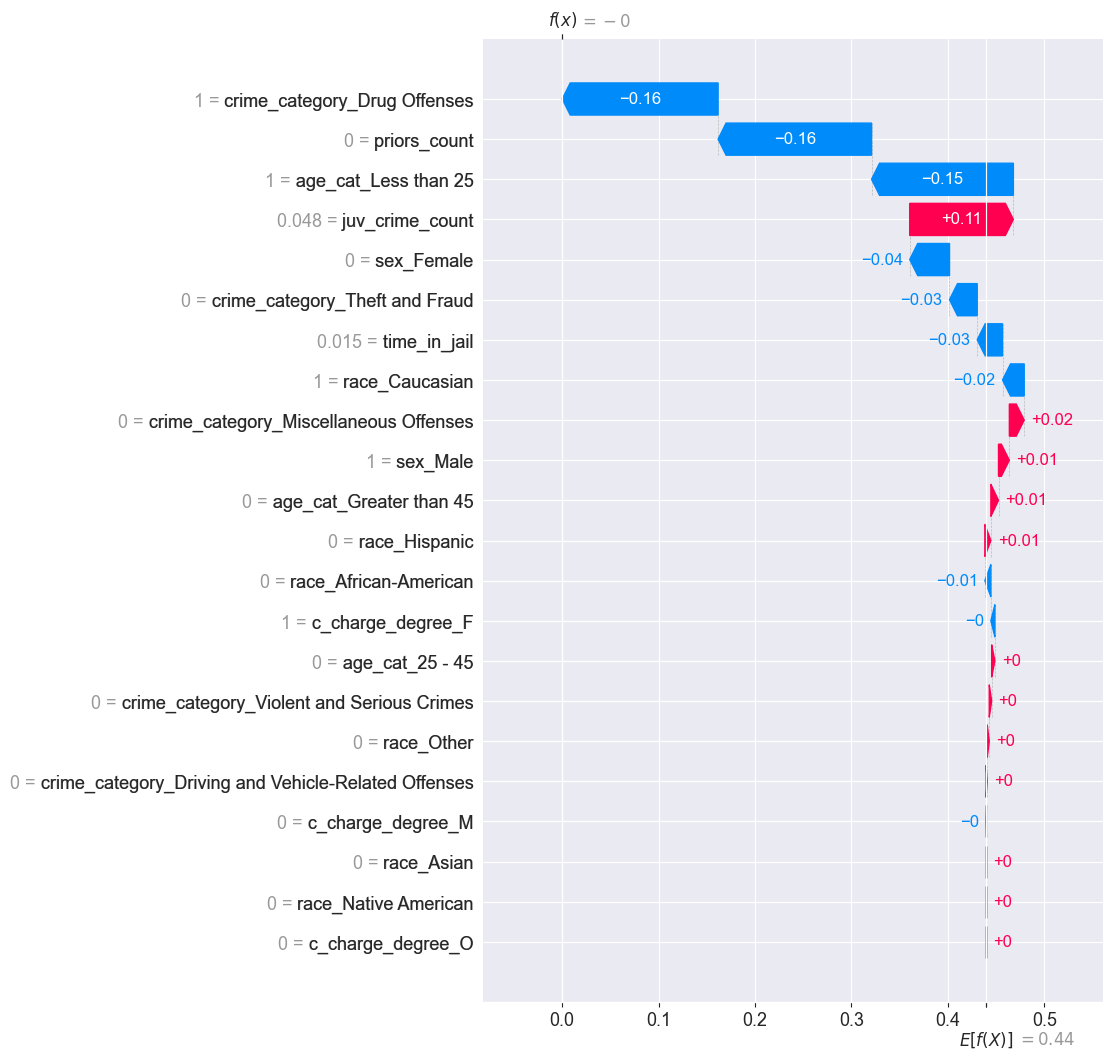

In [ ]:
shap.plots.waterfall(shap_values_dt[index_to_check], max_display=23)

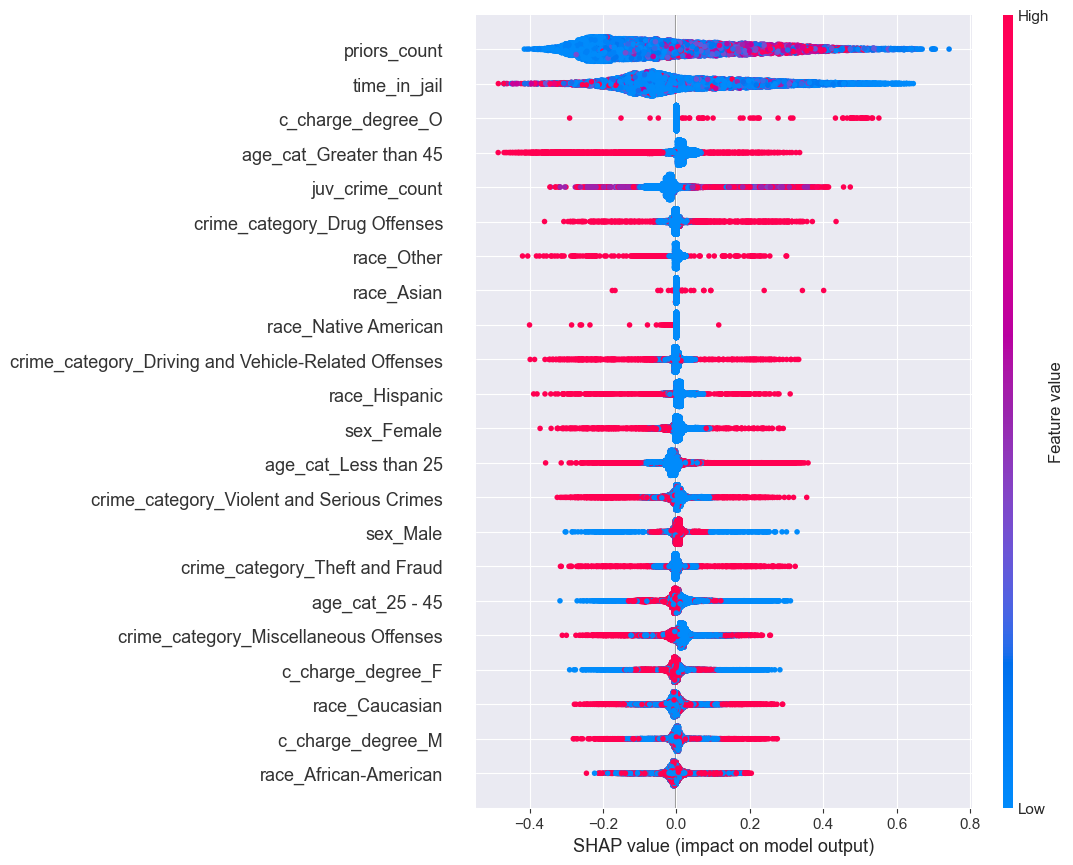

In [ ]:
shap.plots.beeswarm(shap_values_dt, max_display=23, order=shap_values_dt.abs.max(0))

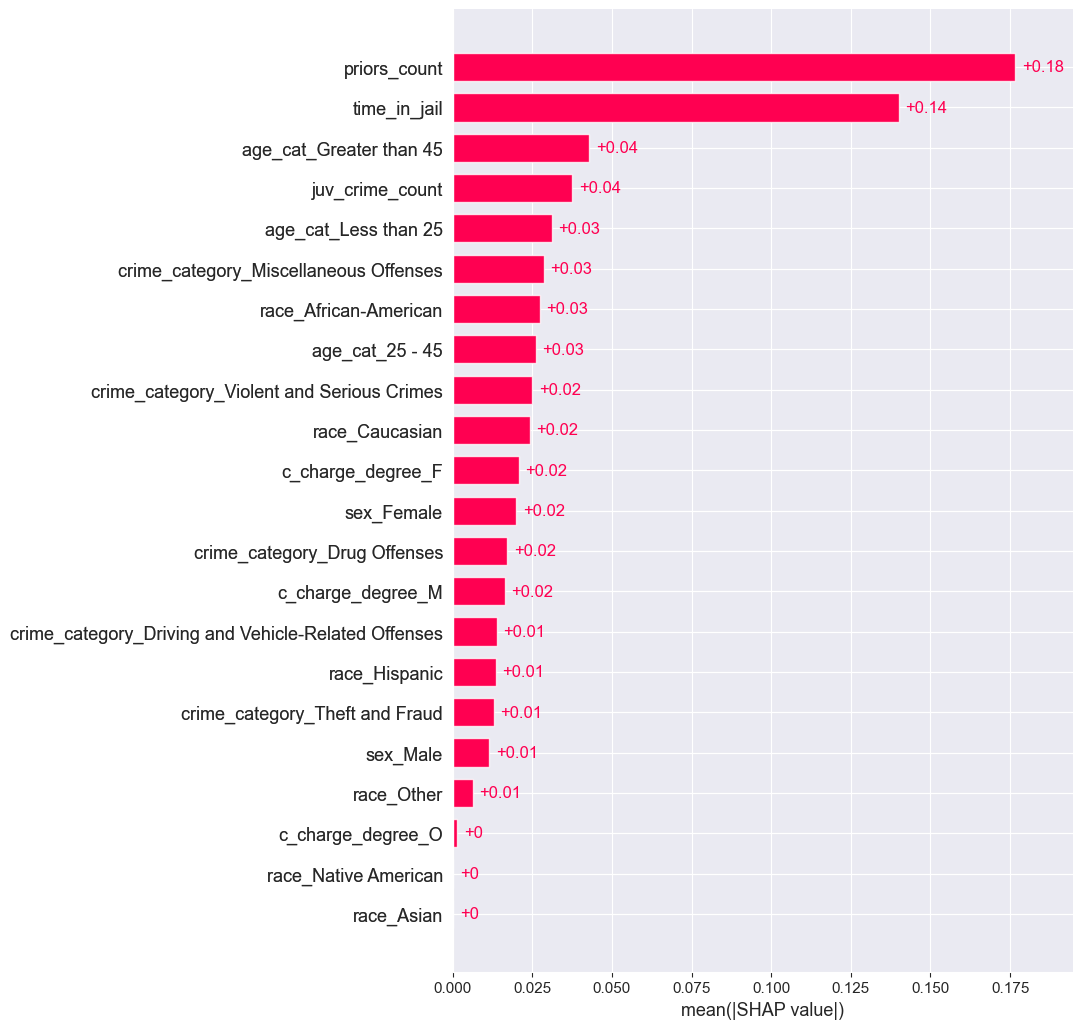

In [ ]:
shap.plots.bar(shap_values_dt.abs.mean(axis=0), max_display=23)

Do you remember the last lab session on Fairness? The question now is, given the feature contribution calculated on this decision tree, what feature do you expect that the fair model trained treats differently?

I've dumped the model for sake of space directly from the notebook of session 2, but you can directly interact with that notebook and import the explainability libraries to do a step by step evaluation of the model's progression in terms of feature contribution

In [ ]:
import joblib
from sklearn.metrics import classification_report

# Load the saved decision tree model
loaded_model = joblib.load('./fair_decision_tree_model.pkl')
y_pred = loaded_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1497
           1       0.67      0.63      0.65      1434

    accuracy                           0.67      2931
   macro avg       0.67      0.67      0.67      2931
weighted avg       0.67      0.67      0.67      2931



In [ ]:
lime = LimeTabular(data=X_train, random_state=42, model=loaded_model)
lime_local = lime.explain_local(X_test[-50:], y_test[-50:], name='LIME')
show(lime_local)

<!-- http://127.0.0.1:7001/12784662512/ -->

Calculate the Shapely Values for this model

In [ ]:
background = shap.maskers.Independent(X, max_samples=1000)
explainer_fair = shap.Explainer(loaded_model.predict, X, seed=42)
shap_values_fair = explainer_fair(X)

PermutationExplainer explainer: 14653it [17:38, 13.71it/s]                           


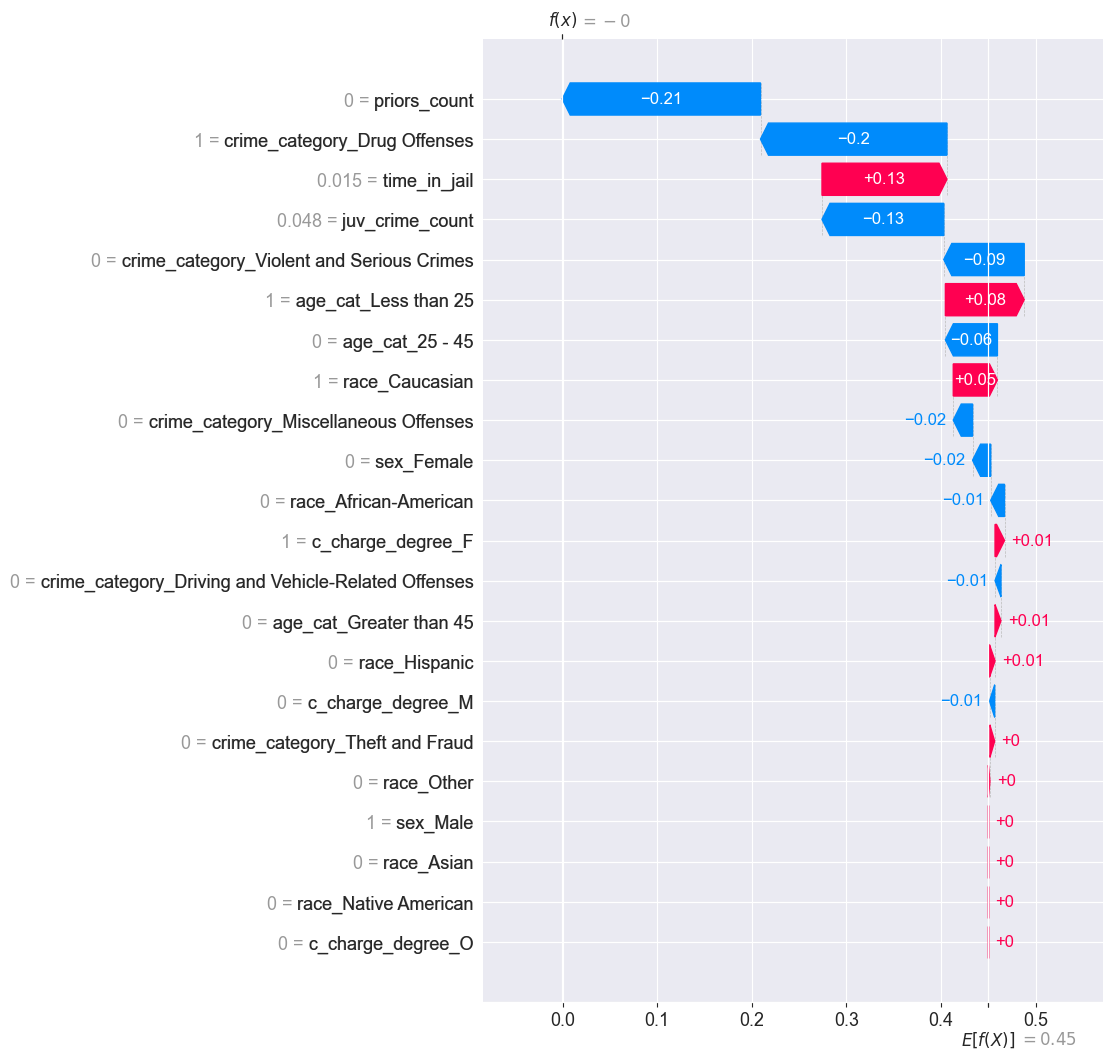

In [ ]:
shap.plots.waterfall(shap_values_fair[index_to_check], max_display=23)

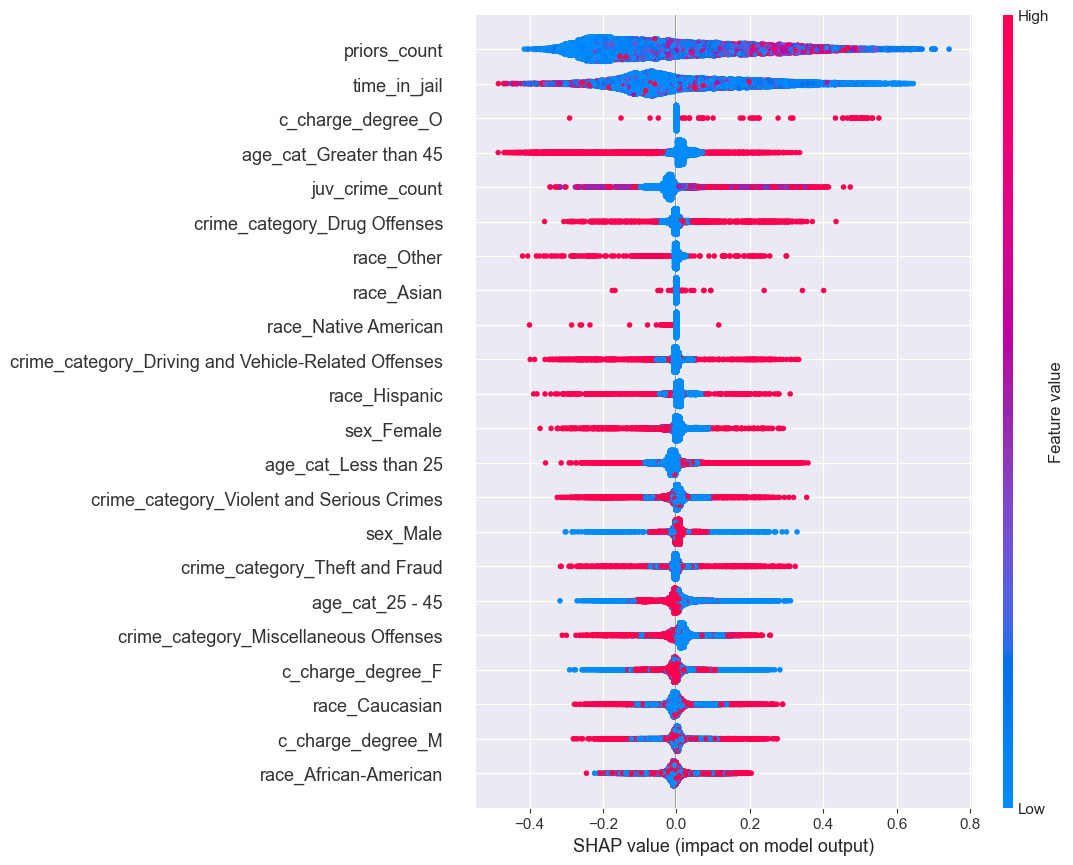

In [ ]:
shap.plots.beeswarm(shap_values_dt, max_display=23, order=shap_values_dt.abs.max(0))

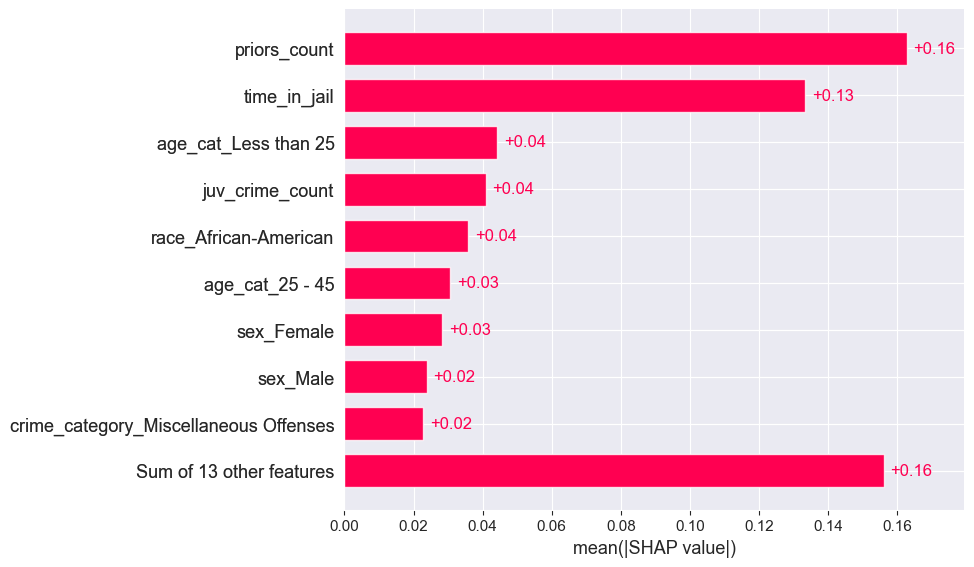

In [ ]:
shap.plots.bar(shap_values_fair.abs.mean(axis=0))

The final model on which we will apply the explainability techniques on is Neural Network (if you recall the image shown in the slide, it is at the top of the performance axis and the lowest in the interpretability axis)

In [ ]:
from keras_tuner.tuners import RandomSearch
from keras.models import Sequential
from keras.layers import Dense, Dropout

# We define a function which will build different configurations for our model
def build_model(hyperparameters):
    model = Sequential()
    model.add(Dense(hyperparameters.Int('input_units', min_value=32, max_value=256, step=32), # Minumum and maximum number of neurons possible for this layer
                    activation='relu',
                    input_shape=(X_train.shape[1],)))

    model.add(Dropout(hyperparameters.Float('dropout',
                                            min_value=0.0, max_value=0.5, step=0.1))) # Minumum and maximum dropout percentage possible for this layer
    # Determines the number of times the loop will run, effectively deciding how many dense layers to add to the model
    for i in range(hyperparameters.Int('n_layers', 1, 3)):
        model.add(Dense(hyperparameters.Int(f'dense_{i}_units', min_value=32, max_value=128, step=32), activation='relu'))

    model.add(Dense(1, activation='sigmoid')) # Output layer
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define the tuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5, # Total number of trials (model configurations) to test at most
    executions_per_trial=1
)

tuner.search(X_train, y_train, epochs=30, validation_split=0.2, verbose=2)

# We save the best hypeparameters found by the Random Search
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

Reloading Tuner from ./untitled_project/tuner0.json


In [ ]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - accuracy: 0.5758 - loss: 0.6748 - val_accuracy: 0.6179 - val_loss: 0.6519
Epoch 2/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - accuracy: 0.6244 - loss: 0.6455 - val_accuracy: 0.6439 - val_loss: 0.6314
Epoch 3/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - accuracy: 0.6366 - loss: 0.6411 - val_accuracy: 0.6512 - val_loss: 0.6242
Epoch 4/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.6408 - loss: 0.6322 - val_accuracy: 0.6678 - val_loss: 0.6191
Epoch 5/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.6490 - loss: 0.6306 - val_accuracy: 0.6588 - val_loss: 0.6184
Epoch 6/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - accuracy: 0.6503 - loss: 0.6289 - val_accuracy: 0.6670 - val_loss: 0.6141
Epoch 7/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.6531 - loss: 0.6290 - val_accuracy: 0.6657 - val_loss: 0.6142
Epoch 8/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.6533 - loss: 0.6279 - 

In [ ]:
explainer = shap.KernelExplainer(model,X_test[:1000])
shap_values_nn = explainer.shap_values(X_test[:1000])

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1000 [00:00<?, ?it/s]

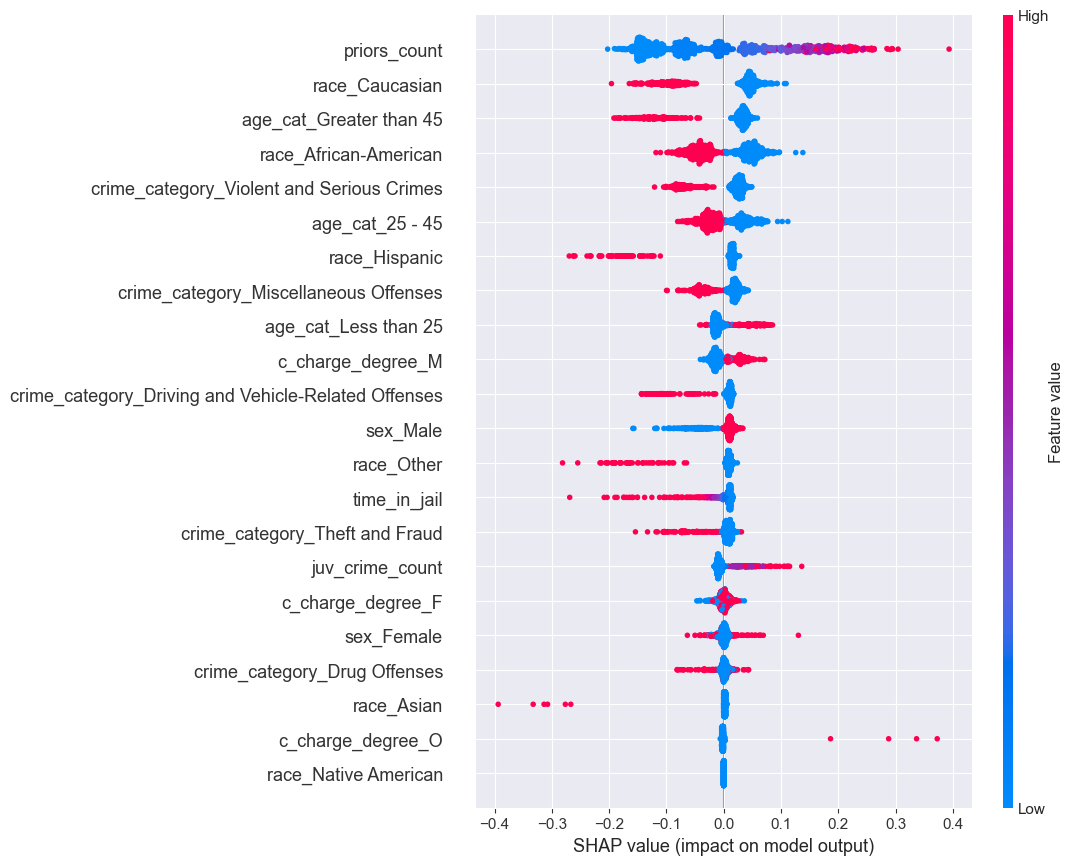

In [ ]:
#shap_values = np.squeeze(shap_values, axis=2)

explanation = shap.Explanation(values=shap_values_nn, base_values=explainer.expected_value, data=X_test[:1000], feature_names=X_test.columns)
shap.plots.beeswarm(explanation, max_display=23)